#NumPy, Pandas, and Matplotlib Integration

Scenario: You are a data analyst working with a dataset of global weather. Your task is to analyze temperature trends and visualize the results.

In [2]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


          Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov  \
City_1   -0.5   2.1   5.4  10.9  16.8  17.7  17.9  16.0  10.4   6.1   0.7   
City_2   24.5  24.4  28.9  33.0  35.0  35.0  35.0  35.0  33.9  28.6  24.0   
City_3   14.3  14.8  20.9  24.5  31.0  31.9  32.5  31.0  26.4  20.3  15.8   
City_4    7.5   9.8  14.3  21.4  25.8  26.8  28.9  25.1  19.7  15.4  11.6   
City_5   -5.0  -5.0  -2.6   3.6   7.3  10.7   9.7   6.6   3.5  -1.6  -5.0   
City_6   -5.0  -5.0  -2.6   4.2   7.8  12.4   8.2   8.6   2.7  -3.2  -5.0   
City_7   -5.0  -5.0  -5.0  -1.8   3.1   6.4   7.8   4.2  -1.8  -5.0  -5.0   
City_8   18.9  20.9  25.1  29.6  35.0  35.0  35.0  35.0  29.7  25.1  20.9   
City_9    8.9  11.0  16.8  20.6  25.9  28.6  26.7  25.6  20.5  17.4  10.4   
City_10  13.3  13.7  20.3  25.5  30.7  32.0  34.3  28.5  25.3  21.4  13.9   

          Dec  
City_1   -1.4  
City_2   24.9  
City_3   14.0  
City_4    9.9  
City_5   -5.0  
City_6   -5.0  
City_7   -5.0  
City_8   18.8  
City_9  

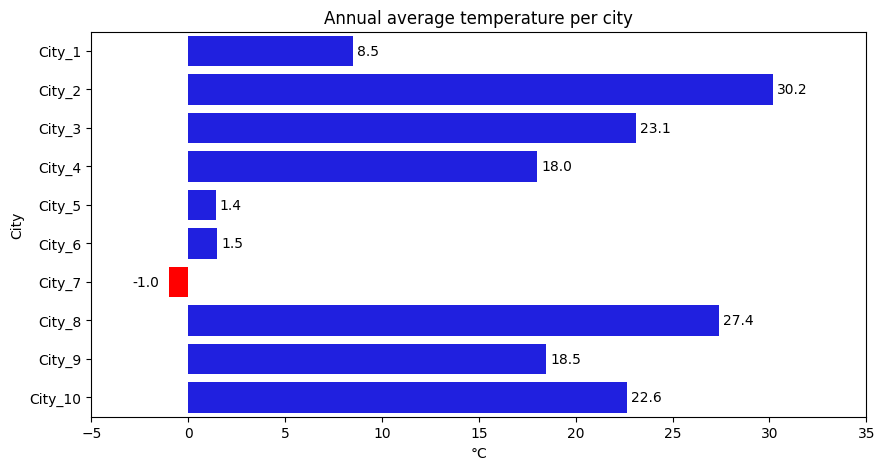

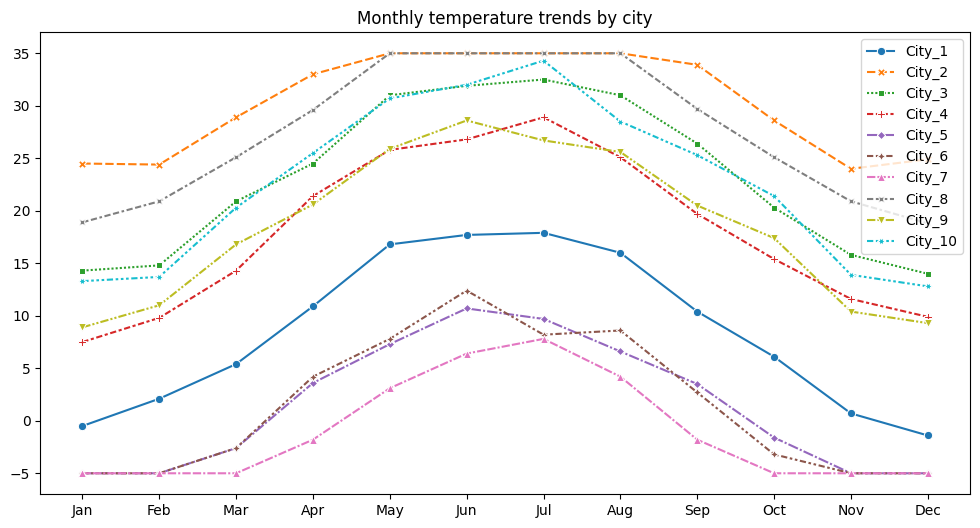

In [35]:
# ----------------------------
# Data Preparation (with seasonality)
# ----------------------------

np.random.seed(42)

# Cities, months
cities = [f'City_{i}' for i in range(1, 11)]
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Base temperature by city (annual average)
city_base = np.random.uniform(-5,35, size=(10,1))

# Seasonal pattern (winter in January, summer in July)
month_seasonality = 10 * np.sin(np.linspace(-np.pi/2, 3*np.pi/2, 12))

# Winter →    Spring →  Summer →  Autumn
#   ↓           ↑          ↑        ↓
# Jan Feb Mar Apr May Jun Jul Aug Sep Oct Nov Dec


# Generate final temperatures with "noise"
temps = city_base + month_seasonality + np.random.normal(0, 1, (10,12))


# # Limit temperatures to the range -5°C to 35°C
temps = np.clip(temps, -5, 35)

# Round for clarity
temps = temps.round(1)


# Create DataFrame
df = pd.DataFrame(temps, index=cities, columns=months)

print(df)


# ----------------------------
# Data Analysis
# ----------------------------

# Annual average per city
df['Annual_Avg'] = df.mean(axis=1)  #  axis=1: collapse COLUMNS → result per row

# Hottest and coldest city using idxmax/idxmin
hottest_city = df['Annual_Avg'].idxmax()
coldest_city = df['Annual_Avg'].idxmin()

print(f"\nHottest city: {hottest_city}")
print(f"Coldest city: {coldest_city}")


# ----------------------------
# Data Visualization
# ----------------------------

plt.figure(figsize=(10,5))

ax = sns.barplot(x=df['Annual_Avg'], y=df.index, color='blue')

for i, patch in enumerate(ax.patches):
    if df['Annual_Avg'].iloc[i] < 0:
        patch.set_facecolor('red')   #red for negative

plt.title("Annual average temperature per city")
plt.xlabel("°C")
plt.ylabel("City")
plt.xlim(-5, 35)

# values ​​to the end of each bar
for i, v in enumerate(df['Annual_Avg']):
    xpos = v - 0.5 if v < 0 else v + 0.2
    ax.text(xpos, i, f"{v:.1f}", va='center', ha='right' if v < 0 else 'left')

plt.show()



plt.figure(figsize=(12,6))
sns.lineplot(data=df[months].T, markers=True)  #transpose

plt.xticks(rotation=0)
plt.title("Monthly temperature trends by city")

plt.show()

#Summary

The dataset shows seasonal trends: temperatures rise in summer and fall in winter. City_2 is the warmest on average, City_7 the coldest, while July is the hottest month and January the coldest (**Northern Hemisphere** pattern).

This is **synthetic data**, generated using **random functions** with a **sine-based** seasonal pattern to mimic natural yearly temperature cycles.